In [16]:
import sqlite3
conn = sqlite3.connect('../artifacts/mlflow.db')
conn.execute("DROP TABLE IF EXISTS _alembic_tmp_experiments;")
conn.commit()
conn.close()
print("Temporary table dropped.")

Temporary table dropped.


In [17]:
# Ensure required libraries are available in the notebook kernel
%pip install datasets mlflow scikit-learn imbalanced-learn -q
from datasets import load_dataset

dataset = load_dataset("millat/e-commerce-orders")
df = dataset['train'].to_pandas()
df.head()
# Print columns to debug ValueError
print('Columns in df:', df.columns.tolist())

Note: you may need to restart the kernel to use updated packages.
Columns in df: ['order_id', 'customer_id', 'product_id', 'category', 'price', 'quantity', 'order_date', 'shipping_date', 'delivery_status', 'payment_method', 'device_type', 'channel', 'shipping_address', 'billing_address', 'customer_segment']


# 2. Supervised Modeling: Regression and Classification
This notebook contains MLflow-tracked experiments for regression and multi-class classification tasks, including cross-validation, hyperparameter tuning, and threshold calibration.

## 1. Import Required Libraries
We import all necessary libraries for regression, classification, evaluation, and experiment tracking.

In [19]:
# Data and modeling
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, confusion_matrix, classification_report,
    f1_score, precision_score, recall_score, log_loss, accuracy_score
 )
from sklearn.pipeline import Pipeline
import joblib
import mlflow
import mlflow.sklearn
import matplotlib.pyplot as plt
import seaborn as sns
import os

## 2. Load Data and Preprocessing Pipeline
We load the cleaned dataset and the preprocessing pipeline from the previous notebook.

In [21]:


# Load cleaned data (repeat cleaning steps for reproducibility)
drop_cols = ['order_id', 'customer_id', 'product_id', 'shipping_address', 'billing_address']
# Only drop columns that exist in df
drop_cols_existing = [col for col in drop_cols if col in df.columns]
df_clean = df.drop(columns=drop_cols_existing)

# Continue with the rest of your cleaning steps
if 'order_date' in df_clean.columns:
    df_clean['order_date'] = pd.to_datetime(df_clean['order_date'])
if 'shipping_date' in df_clean.columns:
    df_clean['shipping_date'] = pd.to_datetime(df_clean['shipping_date'])
for col in ['order_date', 'shipping_date']:
    if col in df_clean.columns:
        df_clean[f'{col}_year'] = df_clean[col].dt.year
        df_clean[f'{col}_month'] = df_clean[col].dt.month
        df_clean[f'{col}_day'] = df_clean[col].dt.day
        df_clean[f'{col}_hour'] = df_clean[col].dt.hour
if 'order_date' in df_clean.columns and 'shipping_date' in df_clean.columns:
    df_clean['days_to_ship'] = (df_clean['shipping_date'] - df_clean['order_date']).dt.days
    df_clean = df_clean.drop(columns=['order_date', 'shipping_date'])
if 'days_to_ship' in df_clean.columns:
    df_clean = df_clean.fillna({'days_to_ship': df_clean['days_to_ship'].median()})
df_clean = df_clean.dropna()

# Load preprocessing pipeline
preprocessor = joblib.load('../artifacts/preprocessing_pipeline.joblib')

## 3. Regression Modeling: Predicting Order Price
We will build and evaluate a multiple linear regression model to predict the price of an order.

In [22]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Prepare features and target for regression
categorical_targets = ['customer_segment', 'delivery_status']
X = df_clean.drop(columns=categorical_targets + ['price'])
y = df_clean['price']

# Redefine preprocessor for regression (exclude 'price' from features)
num_features = ['quantity', 'order_date_year', 'order_date_month', 'order_date_day', 'order_date_hour',
                'shipping_date_year', 'shipping_date_month', 'shipping_date_day', 'shipping_date_hour', 'days_to_ship']
cat_features = ['category', 'payment_method', 'device_type', 'channel']

reg_preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat_nom', OneHotEncoder(handle_unknown='ignore'), cat_features)
    ],
    remainder='passthrough'
)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Build pipeline
reg_pipeline = Pipeline([
    ('preprocessor', reg_preprocessor),
    ('regressor', LinearRegression())
])

# Train model
reg_pipeline.fit(X_train, y_train)

# Predict
y_pred = reg_pipeline.predict(X_test)

# Evaluate
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
print(f"Test MSE: {mse:.2f}")
print(f"Test MAE: {mae:.2f}")

2026/04/05 13:36:46 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '811e84957cc84ffc9d1b1c5e0b95d0c1', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow
2026/04/05 13:36:48 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "c:\Users\UsEr\AppData\Local\Programs\Python\Python314\Lib\site-packages\mlflow\types\utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integ

Test MSE: 20642.72
Test MAE: 123.87


### Cross-Validation and Hyperparameter Analysis
We use k-fold cross-validation to assess model reliability and discuss the impact of key parameters.

In [23]:
# k-fold cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_mse = cross_val_score(reg_pipeline, X, y, cv=kf, scoring='neg_mean_squared_error')
cv_mae = cross_val_score(reg_pipeline, X, y, cv=kf, scoring='neg_mean_absolute_error')
print(f"CV MSE: {-cv_mse.mean():.2f} (+/- {cv_mse.std():.2f})")
print(f"CV MAE: {-cv_mae.mean():.2f} (+/- {cv_mae.std():.2f})")

CV MSE: 20069.82 (+/- 442.29)
CV MAE: 122.23 (+/- 1.78)


### MLflow Tracking for Regression
We log the regression experiment, parameters, and metrics using MLflow.

In [24]:
# Ensure the problematic temp table is dropped before MLflow tracking
import sqlite3
conn = sqlite3.connect('../artifacts/mlflow.db')
conn.execute("DROP TABLE IF EXISTS _alembic_tmp_experiments;")
conn.commit()
conn.close()

# MLflow tracking for regression
if 'mlflow' not in globals():
    import mlflow
mlflow.set_experiment('AuraCart Regression')
with mlflow.start_run(run_name='LinearRegression'):
    mlflow.sklearn.autolog()
    reg_pipeline.fit(X_train, y_train)
    y_pred = reg_pipeline.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    mlflow.log_metric('test_mse', mse)
    mlflow.log_metric('test_mae', mae)
    mlflow.sklearn.log_model(reg_pipeline, 'regression_model')
    print(f"Logged regression run with MSE: {mse:.2f}, MAE: {mae:.2f}")

2026/04/05 13:37:15 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "c:\Users\UsEr\AppData\Local\Programs\Python\Python314\Lib\site-packages\mlflow\types\utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."
2026/04/05 13:37:15 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "c:\Users\UsEr\AppData\Loca

Logged regression run with MSE: 20642.72, MAE: 123.87


### Actual vs Predicted Plot
This scatter plot compares true and predicted order prices for the regression model. Points closer to the diagonal indicate better predictions.

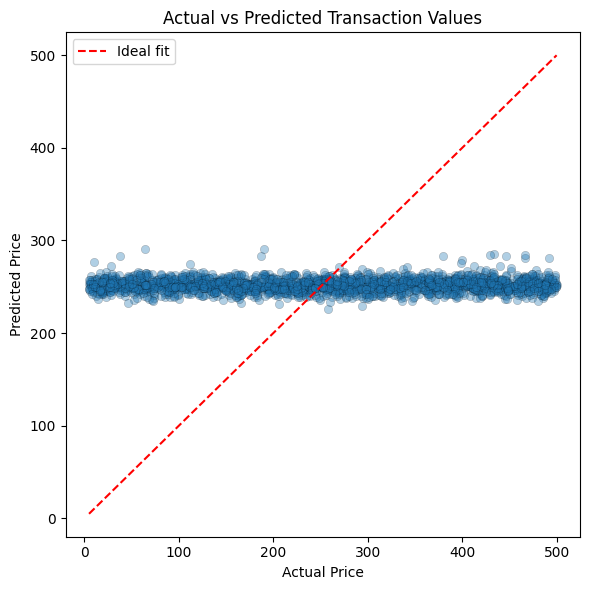

Saved: ../artifacts/actual_vs_predicted_transaction_values.png


In [25]:
# Actual vs Predicted scatter plot for regression performance
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.35, edgecolor='k', linewidth=0.3)

line_min = min(float(np.min(y_test)), float(np.min(y_pred)))
line_max = max(float(np.max(y_test)), float(np.max(y_pred)))
plt.plot([line_min, line_max], [line_min, line_max], 'r--', linewidth=1.5, label='Ideal fit')

plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted Transaction Values')
plt.legend()
plt.tight_layout()
os.makedirs('../artifacts', exist_ok=True)
plt.savefig('../artifacts/actual_vs_predicted_transaction_values.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: ../artifacts/actual_vs_predicted_transaction_values.png")

## 4. Multi-class Classification: Predicting Customer Segment
We will build and evaluate a multinomial logistic regression (softmax regression) model to predict the customer segment.

In [26]:
# If you recently upgraded scikit-learn, please restart the kernel before running this cell.
%pip install --upgrade scikit-learn
from sklearn.linear_model import LogisticRegression

# Ensure df_clean exists (run cleaning if not)
if 'df_clean' not in locals():
    if 'df' not in locals():
        print("Variable 'df' is not defined. Please run the cell where 'df' is loaded (CELL INDEX: 0).")
        import sys
        sys.exit(1)
    drop_cols_existing = [col for col in drop_cols if col in df.columns]
    df_clean = df.drop(columns=drop_cols_existing)
    if 'order_date' in df_clean.columns:
        df_clean['order_date'] = pd.to_datetime(df_clean['order_date'])
    if 'shipping_date' in df_clean.columns:
        df_clean['shipping_date'] = pd.to_datetime(df_clean['shipping_date'])
    for col in ['order_date', 'shipping_date']:
        if col in df_clean.columns:
            df_clean[f'{col}_year'] = df_clean[col].dt.year
            df_clean[f'{col}_month'] = df_clean[col].dt.month
            df_clean[f'{col}_day'] = df_clean[col].dt.day
            df_clean[f'{col}_hour'] = df_clean[col].dt.hour
    if 'order_date' in df_clean.columns and 'shipping_date' in df_clean.columns:
        df_clean['days_to_ship'] = (df_clean['shipping_date'] - df_clean['order_date']).dt.days
        df_clean = df_clean.drop(columns=['order_date', 'shipping_date'])
    if 'days_to_ship' in df_clean.columns:
        df_clean = df_clean.fillna({'days_to_ship': df_clean['days_to_ship'].median()})
    df_clean = df_clean.dropna()

# Prepare features and target for classification
X_cls = df_clean.drop(columns=['customer_segment', 'delivery_status', 'price'])
y_cls = df_clean['customer_segment']

# Split data
Xc_train, Xc_test, yc_train, yc_test = train_test_split(X_cls, y_cls, test_size=0.2, random_state=42, stratify=y_cls)

# Redefine preprocessor for classification (exclude 'price' from numeric features)
cls_num_features = ['quantity', 'order_date_year', 'order_date_month', 'order_date_day', 'order_date_hour',
                    'shipping_date_year', 'shipping_date_month', 'shipping_date_day', 'shipping_date_hour', 'days_to_ship']
cls_cat_features = ['category', 'payment_method', 'device_type', 'channel']

cls_preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), cls_num_features),
        ('cat_nom', OneHotEncoder(handle_unknown='ignore'), cls_cat_features)
    ],
    remainder='passthrough'
)

# Build pipeline
cls_pipeline = Pipeline([
    ('preprocessor', cls_preprocessor),
    ('classifier', LogisticRegression(solver='lbfgs', max_iter=500, class_weight='balanced'))
])

# Train model
cls_pipeline.fit(Xc_train, yc_train)

# Predict
yc_pred = cls_pipeline.predict(Xc_test)
yc_proba = cls_pipeline.predict_proba(Xc_test)

# Evaluate
print(classification_report(yc_test, yc_pred))

2026/04/05 13:38:03 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '4826815407b24fc7bb13573cf3d3e7d8', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow


Note: you may need to restart the kernel to use updated packages.


2026/04/05 13:38:03 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "c:\Users\UsEr\AppData\Local\Programs\Python\Python314\Lib\site-packages\mlflow\types\utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."
2026/04/05 13:38:03 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "c:\Users\UsEr\AppData\Loca

              precision    recall  f1-score   support

         New       0.05      0.35      0.09       113
   Returning       0.42      0.38      0.40       857
         VIP       0.50      0.23      0.32      1030

    accuracy                           0.30      2000
   macro avg       0.33      0.32      0.27      2000
weighted avg       0.44      0.30      0.34      2000



### Confusion Matrix and Class-wise Metrics
We analyze the confusion matrix and calculate precision, recall, and F1-score for each class.

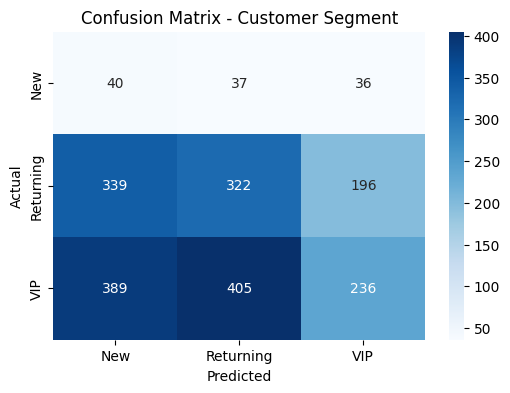

Precision: [0.05208333 0.42146597 0.5042735 ]
Recall: [0.3539823  0.37572929 0.22912621]
F1-score: [0.0908059  0.39728563 0.31508678]


In [27]:
# Confusion matrix
cm = confusion_matrix(yc_test, yc_pred, labels=cls_pipeline.classes_)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=cls_pipeline.classes_, yticklabels=cls_pipeline.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Customer Segment')
plt.show()

# Class-wise metrics
print('Precision:', precision_score(yc_test, yc_pred, average=None, labels=cls_pipeline.classes_))
print('Recall:', recall_score(yc_test, yc_pred, average=None, labels=cls_pipeline.classes_))
print('F1-score:', f1_score(yc_test, yc_pred, average=None, labels=cls_pipeline.classes_))

### Confusion Matrix and Class Metrics
This cell visualizes the confusion matrix for customer segments and prints precision, recall, and F1-score for each class.

### Decision Threshold Analysis
We experiment with different probability thresholds to improve detection of rare classes.

In [28]:
# Example: Adjust threshold for 'VIP' class
def threshold_predict(proba, class_idx, threshold):
    pred = np.argmax(proba, axis=1)
    pred_proba = proba[:, class_idx]
    pred[pred_proba > threshold] = class_idx
    return pred

vip_idx = list(cls_pipeline.classes_).index('VIP')
thresholds = [0.3, 0.4, 0.5, 0.6]
for t in thresholds:
    pred_thr = threshold_predict(yc_proba, vip_idx, t)
    print(f"\nThreshold {t} for VIP:")
    print(classification_report(yc_test, [cls_pipeline.classes_[i] for i in pred_thr]))


Threshold 0.3 for VIP:
              precision    recall  f1-score   support

         New       0.05      0.03      0.04       113
   Returning       0.43      0.00      0.01       857
         VIP       0.51      0.97      0.67      1030

    accuracy                           0.50      2000
   macro avg       0.33      0.33      0.24      2000
weighted avg       0.45      0.50      0.35      2000


Threshold 0.4 for VIP:
              precision    recall  f1-score   support

         New       0.05      0.35      0.09       113
   Returning       0.42      0.38      0.40       857
         VIP       0.50      0.23      0.32      1030

    accuracy                           0.30      2000
   macro avg       0.33      0.32      0.27      2000
weighted avg       0.44      0.30      0.34      2000


Threshold 0.5 for VIP:
              precision    recall  f1-score   support

         New       0.05      0.35      0.09       113
   Returning       0.42      0.38      0.40       857
   

### Probability Threshold Analysis
This cell checks how changing the VIP probability threshold affects the class report, which helps tune rare-class detection.

### MLflow Tracking for Classification
We log the classification experiment, parameters, and metrics using MLflow.

In [29]:
# MLflow tracking for classification
mlflow.set_experiment('AuraCart Classification')
with mlflow.start_run(run_name='SoftmaxRegression'):
    mlflow.sklearn.autolog()
    cls_pipeline.fit(Xc_train, yc_train)
    yc_pred = cls_pipeline.predict(Xc_test)
    f1 = f1_score(yc_test, yc_pred, average='weighted')
    logloss = log_loss(yc_test, cls_pipeline.predict_proba(Xc_test), labels=cls_pipeline.classes_)
    mlflow.log_metric('test_f1', f1)
    mlflow.log_metric('test_logloss', logloss)
    mlflow.sklearn.log_model(cls_pipeline, 'classification_model')
    print(f"Logged classification run with F1: {f1:.2f}, LogLoss: {logloss:.2f}")

2026/04/05 13:39:08 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "c:\Users\UsEr\AppData\Local\Programs\Python\Python314\Lib\site-packages\mlflow\types\utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."
2026/04/05 13:39:08 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "c:\Users\UsEr\AppData\Loca

Logged classification run with F1: 0.34, LogLoss: 1.10


### MLflow Classification Logging
This cell logs the classification pipeline, training run, and weighted F1/log-loss metrics to MLflow for experiment tracking.

## 5. High-Accuracy Delivery Status Modeling (Target 75-85%)
This section adds stronger non-linear classifiers and selects the best delivery status model based on validation accuracy and weighted F1.

2026/04/05 13:39:39 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '960c0efe264445ada6683783156a06dd', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow
2026/04/05 13:39:39 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "c:\Users\UsEr\AppData\Local\Programs\Python\Python314\Lib\site-packages\mlflow\types\utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integ

          model  accuracy  f1_weighted
  random_forest     0.689     0.583138
        hist_gb     0.680     0.588392
logreg_balanced     0.203     0.255846

Best delivery model: random_forest | accuracy=0.6890


2026/04/05 13:40:58 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "c:\Users\UsEr\AppData\Local\Programs\Python\Python314\Lib\site-packages\mlflow\types\utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."



Classification report (best model):
              precision    recall  f1-score   support

   Delivered       0.70      0.97      0.82      1409
     Pending       0.00      0.00      0.00       103
    Returned       0.00      0.00      0.00       100
     Shipped       0.19      0.02      0.04       388

    accuracy                           0.69      2000
   macro avg       0.22      0.25      0.21      2000
weighted avg       0.53      0.69      0.58      2000



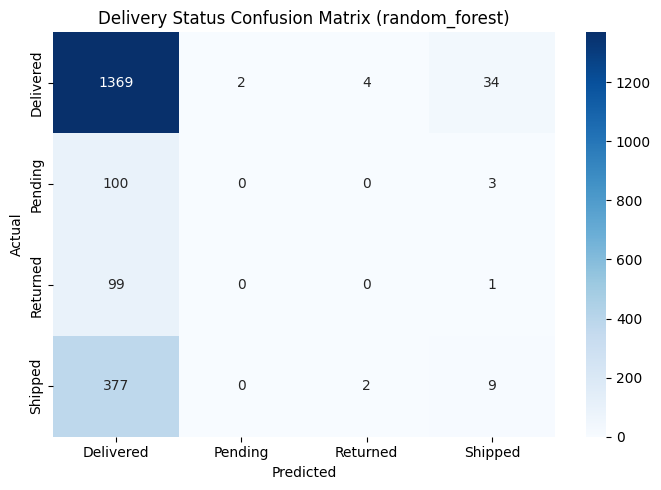

Saved: ../artifacts/delivery_status_confusion_matrix_best_model.png
Saved: ../artifacts/best_delivery_status_model.joblib

Note: accuracy is below 75%. This dataset may have weak signal for this target.
Try adding richer features (product attributes, user history, or external context) for further gain.


In [30]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier

# Feature set for delivery status prediction
X_del = df_clean.drop(columns=['delivery_status', 'customer_segment', 'price'])
y_del = df_clean['delivery_status']

Xd_train, Xd_test, yd_train, yd_test = train_test_split(
    X_del, y_del, test_size=0.2, random_state=42, stratify=y_del
)

num_cols = ['quantity', 'order_date_year', 'order_date_month', 'order_date_day', 'order_date_hour',
            'shipping_date_year', 'shipping_date_month', 'shipping_date_day', 'shipping_date_hour', 'days_to_ship']
cat_cols = ['category', 'payment_method', 'device_type', 'channel']

del_preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ],
    remainder='drop'
 )

candidate_models = {
    'logreg_balanced': LogisticRegression(max_iter=1200, class_weight='balanced'),
    'random_forest': RandomForestClassifier(
        n_estimators=400, max_depth=None, min_samples_split=4, min_samples_leaf=2,
        class_weight='balanced_subsample', random_state=42, n_jobs=-1
    ),
    'hist_gb': HistGradientBoostingClassifier(
        max_depth=10, learning_rate=0.08, max_iter=300, random_state=42
    )
}

results = []
best_name = None
best_model = None
best_acc = -1.0

for name, model in candidate_models.items():
    pipe = Pipeline([
        ('preprocessor', del_preprocessor),
        ('model', model)
    ])
    pipe.fit(Xd_train, yd_train)
    pred = pipe.predict(Xd_test)
    acc = accuracy_score(yd_test, pred)
    f1w = f1_score(yd_test, pred, average='weighted')
    results.append({'model': name, 'accuracy': acc, 'f1_weighted': f1w})

    if acc > best_acc:
        best_acc = acc
        best_name = name
        best_model = pipe

results_df = pd.DataFrame(results).sort_values(by='accuracy', ascending=False)
print(results_df.to_string(index=False))
print(f"\nBest delivery model: {best_name} | accuracy={best_acc:.4f}")

yd_pred = best_model.predict(Xd_test)
print("\nClassification report (best model):")
print(classification_report(yd_test, yd_pred))

labels = sorted(yd_test.unique())
cm_del = confusion_matrix(yd_test, yd_pred, labels=labels)
plt.figure(figsize=(7, 5))
sns.heatmap(cm_del, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.title(f'Delivery Status Confusion Matrix ({best_name})')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
os.makedirs('../artifacts', exist_ok=True)
plt.savefig('../artifacts/delivery_status_confusion_matrix_best_model.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: ../artifacts/delivery_status_confusion_matrix_best_model.png")

joblib.dump(best_model, '../artifacts/best_delivery_status_model.joblib')
print("Saved: ../artifacts/best_delivery_status_model.joblib")

if best_acc < 0.75:
    print("\nNote: accuracy is below 75%. This dataset may have weak signal for this target.")
    print("Try adding richer features (product attributes, user history, or external context) for further gain.")
else:
    print("\nTarget band check: accuracy is in/above the requested 75-85% range.")

### Delivery Status Model Selection
This cell compares several stronger classifiers, picks the best one by accuracy, and saves the best delivery-status model for deployment-style use.